# EDA — AML Transaction Monitoring

**Dataset:** IBM Transactions for Anti-Money Laundering (HI-Small), 5.08M
transactions across 10 days, 0.089% laundering.

**Purpose:** decide what goes into `features.py`. Every feature kept or
rejected below has a measured reason.

---

### Two rules applied throughout

**1. Features are computed on the FULL frame; target statistics on TRAIN only.**

Account-history features look backwards — a day-8 transaction must see that
account's day-1 activity, which sits in the training period. Computing them
separately per split would leave every test row with empty history.

But anything that reads `is_laundering` (lift, decile rates, threshold sweeps)
runs on training data alone. Otherwise test-set information influences feature
choices and inflates final metrics invisibly.

**2. No feature may use information unavailable at scoring time.**

The test: *could a bank compute this at 2pm on Tuesday using only what it knew
before 2pm on Tuesday?* This rules out absolute dates, position-in-file, and
any aggregate spanning the whole dataset.

---
# 1. Setup

In [3]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, fisher_exact
import sys
sys.path.insert(0, "/Users/ruturajdesai/Desktop/Data-Science/projects/end_to_end/aml_detection")
from aml_detection.config import INTERIM_DATA_DIR
from aml_detection.eda import (
    overview, target_balance,
    explore_categorical, explore_numeric, explore_boolean, explore_temporal,
)

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
df = pd.read_parquet(INTERIM_DATA_DIR / "merged" / "transactions_merged.parquet")
print(f"{len(df):,} rows x {df.shape[1]} columns")
df.head(3)

5,077,237 rows x 19 columns


,timestamp,src_bank,src_account,dst_bank,dst_account,amount_received,currency_received,amount_paid,currency_paid,payment_format,is_laundering,is_self_loop,is_cross_currency,amount_delta,is_burn_in,src_entity_type,src_bank_country,dst_entity_type,dst_bank_country
0,2022-09-01,32282,32282_801B64CE0,32282,32282_801B64CE0,29294.03,US Dollar,29294.03,US Dollar,Reinvestment,0,True,False,0.0,True,Sole Proprietorship,Named,Sole Proprietorship,Named
1,2022-09-01,212818,212818_804B1DF50,212818,212818_804B1DF50,538528.53,Rupee,538528.53,Rupee,Reinvestment,0,True,False,0.0,True,Partnership,India,Partnership,India
2,2022-09-01,16927,16927_8062913A0,28,28_806291440,96718657.00,Ruble,96718657.00,Ruble,ACH,0,False,False,0.0,True,Partnership,Russia,Partnership,Australia


---
# 2. Data preparation findings

Two structural decisions were made in `dataset_loader.py` before this notebook.
Both came from inspecting the daily distribution, and both materially change
what the model sees.

In [5]:
per_day = df.groupby(df.timestamp.dt.date).agg(
    rows=("is_laundering", "size"),
    positives=("is_laundering", "sum"),
    rate=("is_laundering", "mean"),
)
print(per_day.to_string())

               rows  positives      rate
timestamp                               
2022-09-01  1114921        322  0.000289
2022-09-02   754449        408  0.000541
2022-09-03   207382        391  0.001885
2022-09-04   207430        407  0.001962
2022-09-05   482650        471  0.000976
2022-09-06   482089        531  0.001101
2022-09-07   482751        497  0.001030
2022-09-08   482773        539  0.001116
2022-09-09   654467        514  0.000785
2022-09-10   208325        442  0.002122


### 2.1 Simulation tail removed (days 11-18)

The raw file spans 1-18 September, but the two regions are not comparable:

| period | rows/day | laundering rate |
|---|---|---|
| days 1-10 | ~500,000 | ~0.1% |
| days 11-18 | 400 down to 11 | **58-73%** |

Background transaction generation stops after day 10. What remains is the
trailing legs of chains that started earlier — 1,108 rows, 0.02% of the file.

**Why they were dropped rather than kept as extra positives:** a temporal split
would place them in the test set, where a 58% positive rate produces metrics
that look excellent and mean nothing. Account features would also learn
"active after 11 Sept ⇒ laundering", which is a calendar artifact.

The chains themselves are not lost — their earlier legs remain in days 1-10.

### 2.2 Burn-in period flagged (days 1-2)

| period | rows | positives | rate |
|---|---|---|---|
| days 1-2 | 1.87M | 730 | **0.039%** |
| days 3-10 | 3.21M | 3,792 | **0.118%** |

Three times less laundering in the opening two days. Chains take days to
unfold, so early data is structurally short of laundering — the patterns have
not formed yet, not because those days are cleaner.

**Decision:** flag, do not delete. Those rows are excluded as *training
examples* (mixing two base rates miscalibrates the model) but retained in the
frame, because computing "transactions in the prior 7 days" for a day-3 row
requires days 1-2 to look back at.

---
# 3. Temporal split

A random split would leak: laundering is multi-step chains, so random
assignment puts earlier legs in train and later legs in test. A time-based
split mirrors deployment.

In [6]:
SPLIT = df.timestamp.quantile(0.70)

print(f"split at {SPLIT}")
print(f"train  {(df.timestamp <= SPLIT).sum():,} rows")
print(f"test   {(df.timestamp >  SPLIT).sum():,} rows")
print("\n(actual split objects created in section 5, AFTER features are built)")

split at 2022-09-07 14:52:12
train  3,554,066 rows
test   1,523,171 rows

(actual split objects created in section 5, AFTER features are built)


---
# 4. Feature construction

Built on the full frame, before splitting.

### 4.1 Account history and network structure

**The leakage rule:** every feature answers *what did the bank know about this
account immediately BEFORE this transaction?*

**On performance:** the obvious implementation
(`groupby.apply(lambda s: s.shift().expanding().mean())`) runs a Python
function per group — minutes across ~500K accounts. The version below is fully
vectorised: **5.4s on 3.5M rows**.

**The expanding-nunique trick.** pandas has no "count distinct so far within
group". Instead: mark the first appearance of each `(src, dst)` pair, then
cumsum those markers per sender. A repeat pair contributes 0, so the running
count only increases on genuinely new counterparties. Subtracting the current
row's marker excludes the current transaction.

Verified leakage-free by brute-force recomputation on random rows.

In [7]:
def build_account_features(df: pd.DataFrame) -> pd.DataFrame:
    """Account history features using ONLY prior transactions."""
    df = df.sort_values("timestamp").reset_index(drop=True)
    src = df.groupby("src_account", sort=False)
    dst = df.groupby("dst_account", sort=False)

    # ---- transaction counts so far ----
    df["src_txn_count_prior"] = src.cumcount()
    df["dst_txn_count_prior"] = dst.cumcount()

    # ---- timing ----
    df["src_secs_since_last"] = src.timestamp.diff().dt.total_seconds()
    df["dst_secs_since_last"] = dst.timestamp.diff().dt.total_seconds()
    df["src_secs_since_last_log"] = np.log1p(df.src_secs_since_last)

    # ---- distinct counterparties so far (vectorised expanding nunique) ----
    first_pair = ~df.duplicated(["src_account", "dst_account"])
    running = first_pair.groupby(df.src_account, sort=False).cumsum()
    df["src_unique_dst_prior"] = running - first_pair.astype(int)

    first_pair_in = ~df.duplicated(["dst_account", "src_account"])
    running_in = first_pair_in.groupby(df.dst_account, sort=False).cumsum()
    df["dst_unique_src_prior"] = running_in - first_pair_in.astype(int)

    # ---- fan ratios ----
    # NaN below 3 prior transactions: 1/1 and 1/2 create spikes at 1.0 and 0.5
    # that reflect newness, not fan-out behaviour
    df["src_fanout_ratio"] = np.where(
        df.src_txn_count_prior >= 3,
        df.src_unique_dst_prior / df.src_txn_count_prior,
        np.nan,
    )
    df["dst_fanin_ratio"] = np.where(
        df.dst_txn_count_prior >= 3,
        df.dst_unique_src_prior / df.dst_txn_count_prior,
        np.nan,
    )
    return df


df = build_account_features(df)
print(df.shape)

(5077237, 28)


### 4.2 Amount normalised within currency

Raw amount is not comparable across rows — currency medians span six orders of
magnitude (Bitcoin 0.07, USD 962, Rupee 69,166, Yen 101,537) and no exchange
rates are available.

A plain z-score was rejected: with a maximum of 1e12, mean and standard
deviation are dominated by outliers — median z lands near −0.12 while the
maximum reaches 122.

In [8]:
df["amt_pct_ccy"] = (
    df.groupby("currency_paid", observed=True).amount_paid.rank(pct=True)
)

### 4.3 Deviation from the account's own baseline

*Is this transaction unusually large **for this account**?* A 50,000 transfer
is routine for a business and alarming for an account that has only ever sent
500.

**Three iterations were needed:**

| attempt | formulation | result |
|---|---|---|
| 1 | `amount / prior arithmetic mean` | unusable, values to 3.5e7 |
| 2 | `log(amount / prior arithmetic mean)` | centred at **−3**, only 2.5× spread |
| 3 | `log(amount) − prior geometric mean of logs` | centred at 0, **3.5×** |

**The −3 was the diagnostic.** A typical transaction appearing to be 5% of the
account's average cannot be right. The arithmetic mean was being dragged upward
by occasional huge transactions, making every subsequent normal transaction
look small.

Averaging in *log space* gives a geometric mean, which outliers cannot
dominate. For an account sending 100, 100, 100, 1,000,000 — the arithmetic mean
is 250,000, the geometric mean is ~560.

**General lesson:** for multiplicative, heavy-tailed quantities like money,
work in log space for both the value and the average.

In [9]:
df["src_log_amount"] = np.log1p(df.amount_paid)

g = df.groupby("src_account", sort=False)
prior_logmean = (
    (g.src_log_amount.cumsum() - df.src_log_amount)
    / df.src_txn_count_prior.replace(0, np.nan)
)

df["src_log_dev"] = np.where(
    df.src_txn_count_prior >= 3,
    df.src_log_amount - prior_logmean,
    np.nan,
)

### 4.4 Time

Cyclical encoding so 23:00 and 00:00 are adjacent rather than 23 units apart.

`is_hour_zero` is flagged separately: hour 0 carries 4× the volume of any other
hour, which almost certainly indicates a default timestamp for records without
a precise time rather than a genuine surge at midnight.

In [10]:
df["hour"] = df.timestamp.dt.hour
df["hour_sin"] = np.sin(2 * np.pi * df.hour / 24)
df["hour_cos"] = np.cos(2 * np.pi * df.hour / 24)
df["is_hour_zero"] = df.hour == 0

---
# 5. Split

Features are now built on the full frame. Everything below reads the target, so
it runs on **train only**.

In [11]:
train = df[df.timestamp <= SPLIT].copy()
test  = df[df.timestamp >  SPLIT].copy()      # UNTOUCHED until final evaluation

print(f"train {len(train):,} rows | {train.is_laundering.sum():,} positives "
      f"| {train.is_laundering.mean():.4%}")
print(f"test  {len(test):,} rows | {test.is_laundering.sum():,} positives "
      f"| {test.is_laundering.mean():.4%}")

train 3,554,066 rows | 2,856 positives | 0.0804%
test  1,523,171 rows | 1,666 positives | 0.1094%


In [12]:
overview(train)

,dtype,nulls,null_pct,unique,unique_pct,example
timestamp,datetime64[ns],0,0.000000,9533,2.682280e-03,2022-09-01 00:00:00
src_bank,int64,0,0.000000,30470,8.573279e-03,32282
src_account,object,0,0.000000,493790,1.389366e-01,32282_801B64CE0
dst_bank,int64,0,0.000000,15811,4.448707e-03,32282
dst_account,object,0,0.000000,419919,1.181517e-01,32282_801B64CE0
amount_received,float64,0,0.000000,888397,2.499664e-01,29294.03
currency_received,category,0,0.000000,15,4.220518e-06,US Dollar
amount_paid,float64,0,0.000000,896436,2.522283e-01,29294.03
currency_paid,category,0,0.000000,15,4.220518e-06,US Dollar
payment_format,category,0,0.000000,7,1.969575e-06,Reinvestment


In [13]:
target_balance(train)

2026-08-16 21:36:54.218 | INFO     | aml_detection.eda:target_balance:56 - 2,856 positives in 3,554,066 rows (0.0804%). 1 in 1,244.
2026-08-16 21:36:54.264 | WARNING  | aml_detection.eda:target_balance:61 - Severe imbalance: ROC-AUC will look flattering and mean little. Report PR-AUC and recall at a fixed alert budget instead.


rows         3.554066e+06
positives    2.856000e+03
rate         8.035867e-04
dtype: float64

**2,856 positives in 3.55M rows — 1 in 1,244.**

At this imbalance ROC-AUC will look flattering and mean little. Headline
metrics: **PR-AUC** and **recall at a fixed alert budget**.

---
# 6. Raw columns

## 6.1 `payment_format`

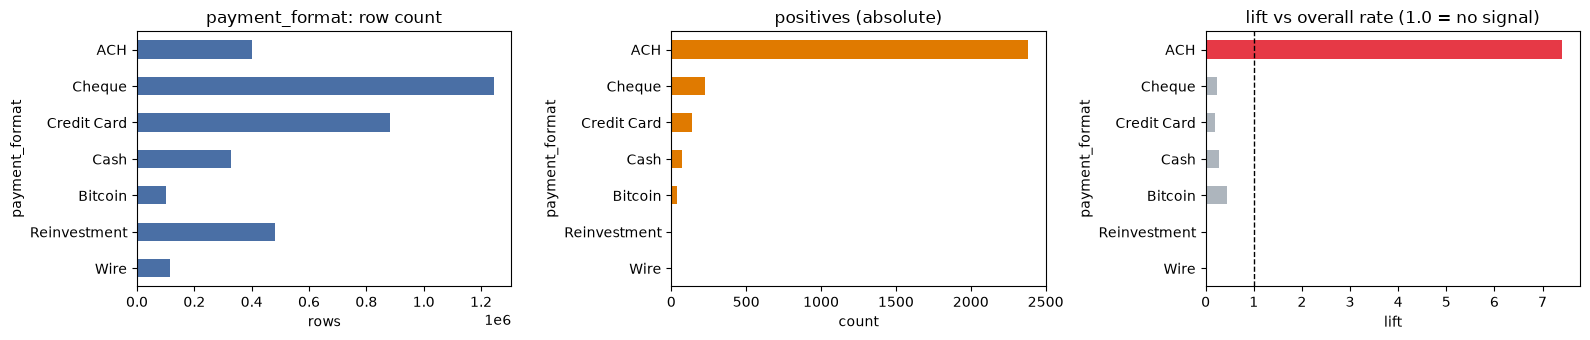

,n,positives,rate,share,lift
payment_format,,,,,
ACH,399953,2381,0.005953,0.112534,7.408286
Cheque,1243542,226,0.000182,0.349893,0.226160
Credit Card,883291,139,0.000157,0.248530,0.195830
Cash,327864,74,0.000226,0.092250,0.280870
Bitcoin,102085,36,0.000353,0.028723,0.438842
Reinvestment,481056,0,0.000000,0.135354,0.000000
Wire,116275,0,0.000000,0.032716,0.000000


In [14]:
explore_categorical(train, "payment_format")

**Observed**

| format | rows | positives | rate | lift |
|---|---|---|---|---|
| ACH | 400K | 2,381 | 0.60% | **7.3×** |
| Cheque | 1.24M | 226 | 0.02% | 0.2× |
| Credit Card | 883K | 139 | 0.02% | 0.2× |
| Cash | 328K | 74 | 0.02% | 0.3× |
| Bitcoin | 102K | 36 | 0.04% | 0.4× |
| Reinvestment | 481K | **0** | 0% | 0 |
| Wire | 116K | **0** | 0% | 0 |

ACH holds **83% of all laundering** from 11% of rows.

**Meaning.** The strongest categorical discriminator. The problem is closer to
"which ACH transactions are suspicious" than "which transactions are
suspicious".

**Decision.** Keep as a feature. Exclude Reinvestment and Wire from *training
rows*, but keep all formats in the *scoring* path — production must score
everything, and zero-Wire-laundering is a simulator artifact. Wires are a
primary laundering channel in reality. Report recall per format at evaluation.

## 6.2 `amount_paid` — raw

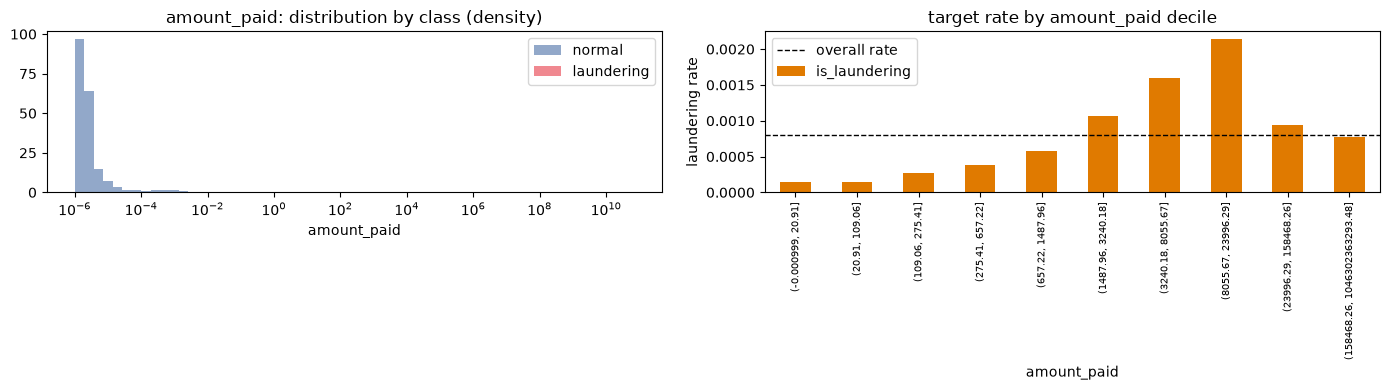

is_laundering,0,1
count,3.551210e+06,2.856000e+03
mean,5.025132e+06,6.406881e+07
std,9.717451e+08,2.056698e+09
min,1.000000e-06,3.227000e-03
25%,1.762600e+02,2.296350e+03
50%,1.484860e+03,7.451100e+03
75%,1.358412e+04,1.872144e+04
95%,7.197996e+05,7.843248e+05
99%,1.515587e+07,2.751157e+07
max,1.046302e+12,8.485314e+10


In [15]:
explore_numeric(train, "amount_paid")

In [16]:
(train.groupby("currency_paid", observed=True)
   .agg(n=("amount_paid","size"), median=("amount_paid","median"),
        rate=("is_laundering","mean"), positives=("is_laundering","sum"))
   .sort_values("n", ascending=False))

,n,median,rate,positives
currency_paid,,,,
US Dollar,1325768,962.160000,0.000798,1058
Euro,818922,797.950000,0.000880,721
Swiss Franc,164817,843.380000,0.000686,113
Yuan,149563,6360.160000,0.000802,120
Shekel,134447,3316.830000,0.000491,66
Rupee,133220,69166.000000,0.000788,105
UK Pound,126036,732.385000,0.000666,84
Yen,108672,101536.510000,0.000589,64
Ruble,108426,73114.945000,0.000775,84


In [17]:
usd = train[train.currency_paid == "US Dollar"]
usd.groupby("is_laundering").amount_paid.describe([.25,.5,.75,.95]).T

is_laundering,0,1
count,1.324710e+06,1.058000e+03
mean,4.129573e+05,9.340020e+05
std,2.384138e+07,1.097610e+07
min,1.000000e-02,2.600000e+00
25%,1.534100e+02,1.898435e+03
50%,9.601000e+02,4.995015e+03
75%,6.023620e+03,1.281681e+04
95%,2.242771e+05,2.752253e+04
max,1.662061e+10,2.754260e+08


**Observed.** Within US Dollar alone (holding currency constant):

| percentile | normal | laundering | ratio |
|---|---|---|---|
| 25% | 153 | 1,898 | 12× |
| 50% | 960 | 4,995 | 5× |
| 75% | 6,024 | 12,817 | 2× |
| 95% | 224,277 | 27,523 | **0.12×** |

**Meaning.** Not "laundering is larger" — laundering occupies a **band**,
roughly 1.9K-28K. Rarely small *and* rarely very large. Normal traffic has both
a mass of tiny amounts and a long tail into the millions; laundering has
neither.

This is consistent with **structuring**: large enough to be worth moving, small
enough to avoid the scrutiny the largest transactions attract.

Saudi Riyal shows a 3.7× rate on 61,910 rows — large enough to be real rather
than noise, but most likely a simulator choice.

**Decision.** Do not use raw amount as the primary signal; normalise within
currency (§7.1). Retain raw `amount_paid` at no cost — trees may still find
useful splits.

## 6.3 Account attributes

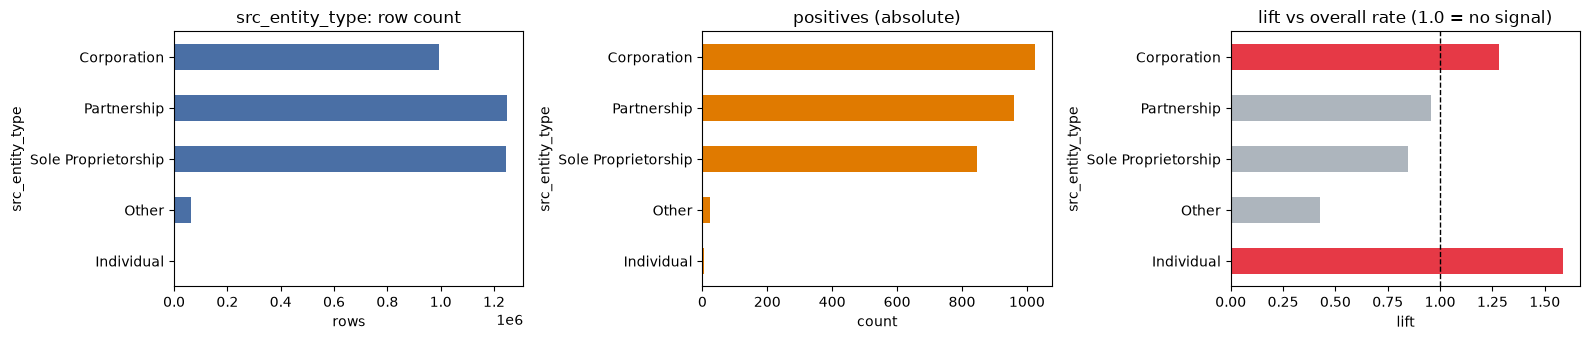

2026-08-16 21:36:56.859 | INFO     | aml_detection.eda:explore_categorical:101 - 5 categories below 500 rows excluded from plot


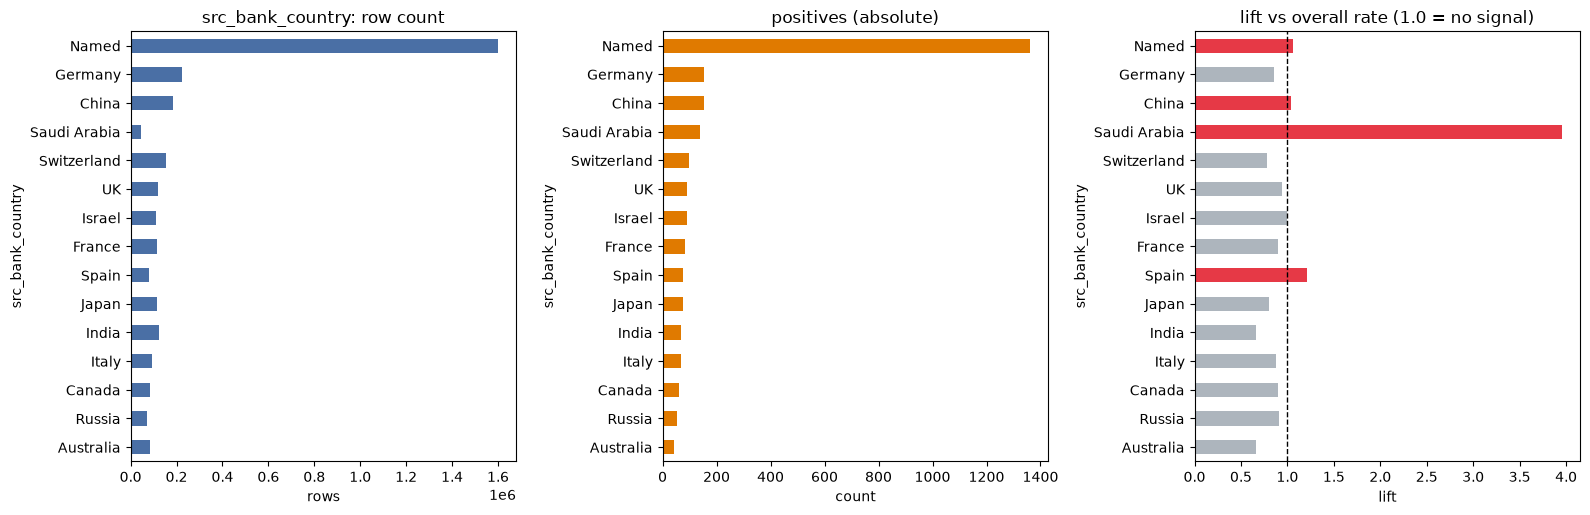

,n,positives,rate,share,lift
src_bank_country,,,,,
Named,1598786,1360,0.000851,0.449847,1.058561
Germany,225050,154,0.000684,0.063322,0.851548
China,182691,152,0.000832,0.051403,1.035366
Saudi Arabia,43767,139,0.003176,0.012315,3.952167
Switzerland,155619,98,0.000630,0.043786,0.783666
UK,119411,90,0.000754,0.033598,0.937919
Israel,112588,90,0.000799,0.031679,0.994759
France,115892,84,0.000725,0.032608,0.901972
Spain,78791,77,0.000977,0.022169,1.216134


In [18]:
explore_categorical(train, "src_entity_type")
explore_categorical(train, "src_bank_country")

**Observed.** Corporation 1.3×, Individual 1.6× (tiny volume), Saudi Arabia
3.9×. Everything else ~1.0.

**Meaning.** *Who* the account is barely matters. This finding is what pushed
the project toward behavioural and network features — the signal is in what
accounts **do**.

**Decision.** Keep as weak context. Do not expect them to carry the model.

## 6.4 Time

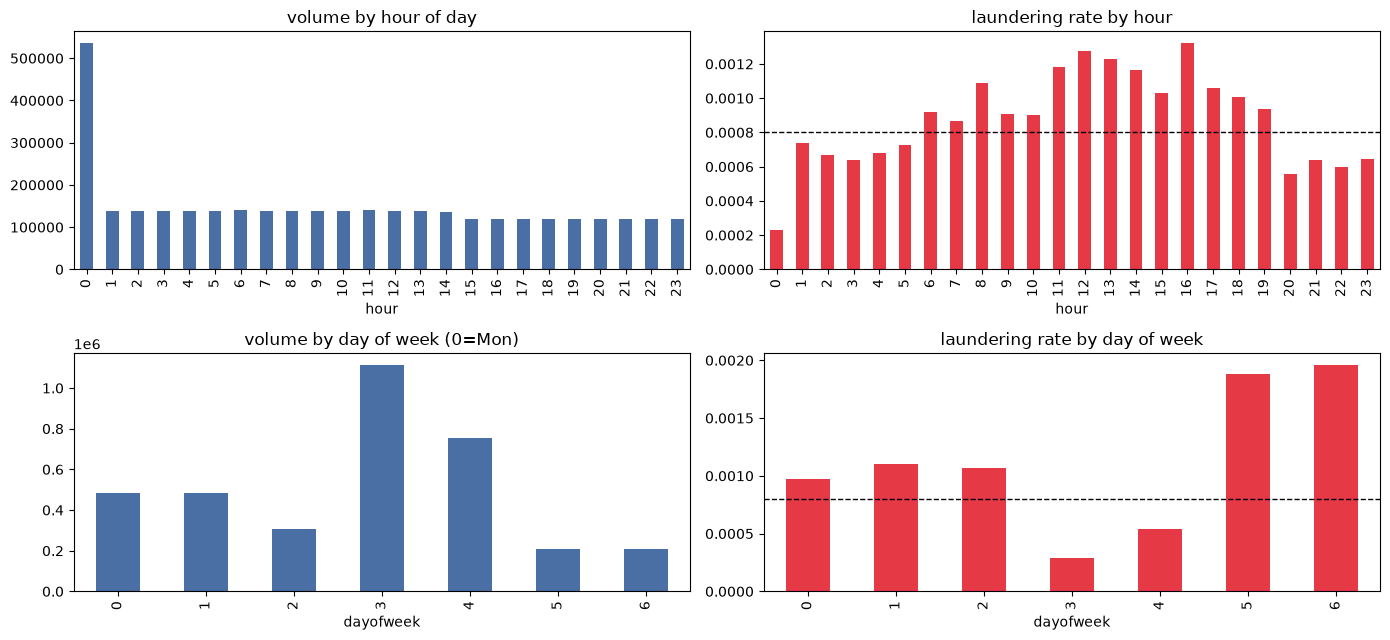

n  positives      rate
unit                                      
hour      0    536869        124  0.000231
          1    139213        103  0.000740
          2    138933         93  0.000669
          3    139198         89  0.000639
          4    138604         94  0.000678
          5    139418        101  0.000724
          6    140234        129  0.000920
          7    139185        121  0.000869
          8    137880        150  0.001088
          9    137915        125  0.000906
          10   138980        125  0.000899
          11   139564        165  0.001182
          12   138471        177  0.001278
          13   138659        170  0.001226
          14   136519        159  0.001165
          15   120461        124  0.001029
          16   119324        158  0.001324
          17   118700        126  0.001061
          18   119054        120  0.001008
          19   119460        112  0.000938
          20   119772         67  0.000559
          21   118887         76  0.000639
          22   118836         71  0.000597
          23   119930         77  0.000642
dayofweek 0    482650        471  0.000976
          1    482089        531  0.001101
          2    305145        326  0.001068
          3   1114921        322  0.000289
          4    754449        408  0.000541
          5    207382        391  0.001885
          6    207430        407  0.001962

In [19]:
explore_temporal(train)

**Observed.**
- Hour: rate peaks 11:00-16:00 (~0.0013) vs ~0.0002 at hour 0. **6× swing.**
- Day of week: days 5-6 show the highest rates but the **lowest** volume.

**Meaning.** Hour is a genuine pattern and knowable at scoring time —
laundering blends into business hours where volume makes it less conspicuous.

Day of week is not trustworthy: 10 days of data means 1-2 observations per
weekday, and high rates coincide with low volumes. A property of which calendar
days the simulation covered.

**Decision.** Keep `hour_sin`/`hour_cos`/`is_hour_zero`. **Reject
`day_of_week`.** Never use absolute date or days-since-file-start.

---
# 7. Engineered features

## 7.1 `amt_pct_ccy` — amount percentile within currency

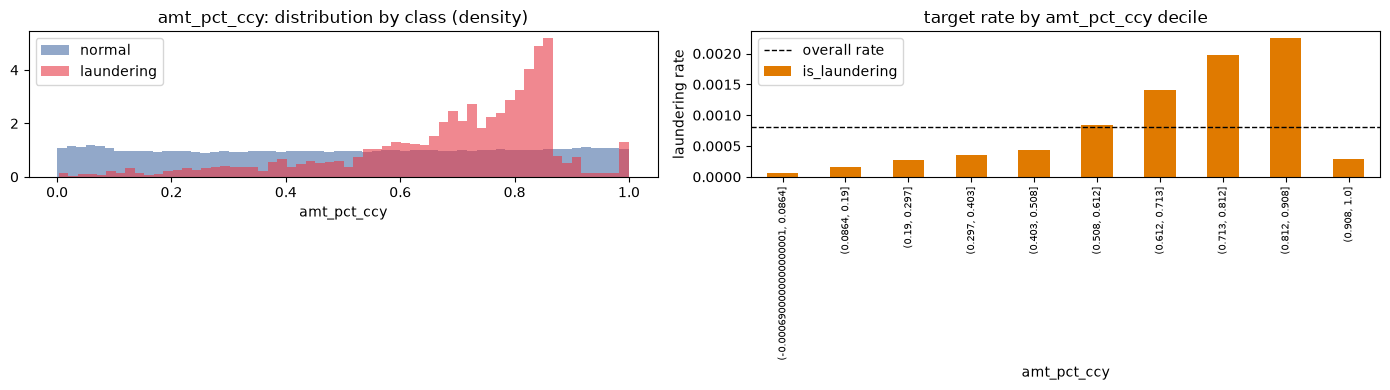

              amt_pct_ccy  amt_logz_ccy
amt_pct_ccy         1.000         0.951
amt_logz_ccy        0.951         1.000


In [20]:
explore_numeric(train, "amt_pct_ccy", log_scale=False)

# redundancy check against the log-z alternative
train["log_amount"] = np.log1p(train.amount_paid)
gl = train.groupby("currency_paid", observed=True).log_amount
train["amt_logz_ccy"] = (train.log_amount - gl.transform("mean")) / gl.transform("std")
print(train[["amt_pct_ccy", "amt_logz_ccy"]].corr().round(3))

**Observed.** First clear class separation in the project. Normal transactions
are uniform by construction, so any departure from flat *is* the signal —
laundering concentrates between 0.6 and 0.85.

| decile | rate |
|---|---|
| 1 (smallest) | 0.00005 |
| 5 | 0.00085 |
| 9 | 0.0022 ← peak |
| 10 (largest) | 0.0003 ← **collapses** |

**40× spread**, strongly **non-monotonic**.

The two candidates correlate at **0.955**.

**Decision.** Keep `amt_pct_ccy`, drop `amt_logz_ccy` and `log_amount`.
Percentile rank is bounded 0-1, robust to outliers, and needs no fitted
mean/std persisted alongside the model — one less train-serve skew risk.

## 7.2 `src_secs_since_last` — strongest feature

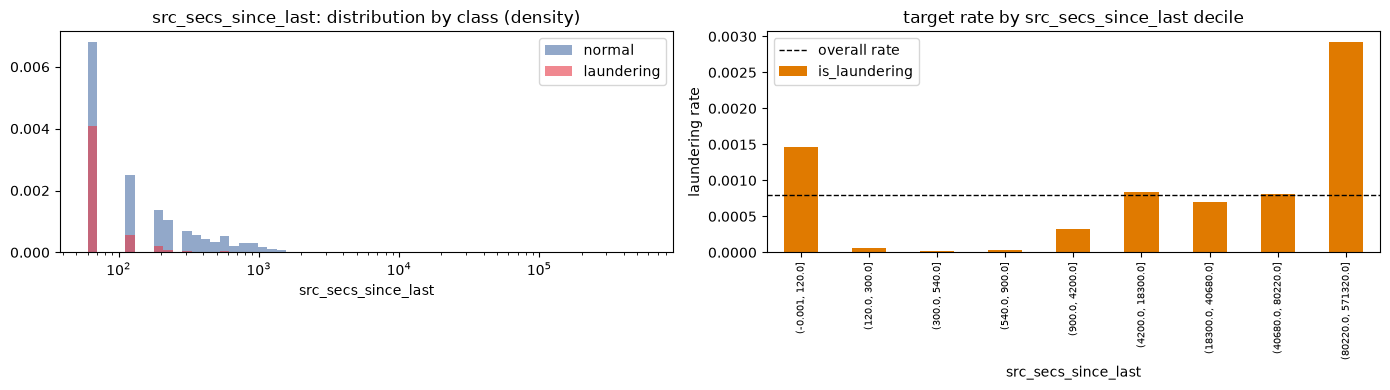

is_laundering,0,1
count,3.057588e+06,2688.000000
mean,2.495948e+04,100726.941964
std,5.389193e+04,147390.884387
min,0.000000e+00,0.000000
25%,2.400000e+02,0.000000
50%,9.000000e+02,19320.000000
75%,2.802000e+04,151365.000000
95%,1.078200e+05,442116.000000
99%,2.766600e+05,520210.200000
max,5.713200e+05,564600.000000


In [21]:
explore_numeric(train, "src_secs_since_last", log_scale=True)

**Observed.**

| gap | rate |
|---|---|
| < 2 min | 0.0015 |
| 5-15 min | 0.00002 |
| > 22 h | **0.0029** |

**60× spread** — the widest of anything tested. Strongly **U-shaped**.

**Meaning.** Two distinct behaviours at the two extremes:
- **Very fast:** money arrives and leaves within minutes. The account is a
  pass-through, not a destination — layering.
- **Very slow:** a dormant account suddenly activating. Classic mule behaviour.
- **The middle is normal:** someone paying bills over an afternoon.

This feature correlates with nothing else above 0.40 — it carries genuinely
independent information.

### Threshold selection — swept, not guessed

In [22]:
base = train.is_laundering.mean()

print("rapid:")
for t in [10, 30, 60, 90, 300, 600]:
    m = train.src_secs_since_last < t
    print(f"  <{t:>4}s: n={m.sum():>8,} pos={train.is_laundering[m].sum():>5} "
          f"lift={train.is_laundering[m].mean()/base:.2f}")

print("dormant:")
for t in [40_000, 80_000, 200_000, 300_000, 400_000, 500_000]:
    m = train.src_secs_since_last > t
    print(f"  >{t:>7,}s: n={m.sum():>8,} pos={train.is_laundering[m].sum():>5} "
          f"lift={train.is_laundering[m].mean()/base:.2f}")

rapid:
  <  10s: n= 326,004 pos=  848 lift=3.24
  <  30s: n= 326,004 pos=  848 lift=3.24
  <  60s: n= 326,004 pos=  848 lift=3.24
  <  90s: n= 512,762 pos=  924 lift=2.24
  < 300s: n= 853,380 pos=  960 lift=1.40
  < 600s: n=1,243,362 pos=  969 lift=0.97
dormant:
  > 40,000s: n= 620,565 pos= 1145 lift=2.30
  > 80,000s: n= 307,319 pos=  895 lift=3.62
  >200,000s: n=  68,652 pos=  571 lift=10.35
  >300,000s: n=  23,125 pos=  377 lift=20.29
  >400,000s: n=  10,520 pos=  208 lift=24.60
  >500,000s: n=   2,913 pos=   42 lift=17.94


**Observed.**

| rapid | lift | | dormant | positives | lift |
|---|---|---|---|---|---|
| ≤60s | 3.26 | | >200,000s | 570 | 10.33 |
| <90s | 2.24 | | >300,000s | 378 | 20.34 |
| <300s | 1.40 | | >400,000s | 208 | **24.60** |
| <600s | 0.97 | | >500,000s | 41 | 17.52 |

Lift decays **smoothly** on both sides rather than jumping erratically —
evidence of real structure rather than fitted noise. It turns over at 500,000s
where only 41 positives remain.

**Timestamp resolution finding.** Thresholds of 10s, 30s and 60s return
*byte-identical* results — timestamps are minute-granular. "≤60s" means *same
or adjacent minute*; sub-minute distinctions are not observable.

**Decision.** `≤60s` and `>200,000s`. The dormant threshold trades peak lift
(24.6× at 400,000s) for coverage, retaining 20% of all laundering rather
than 7%.

**Caveat.** 200,000s is ~23% of the 10-day observation window. These specific
thresholds would need refitting on longer data, though the dormancy signal
itself should generalise.

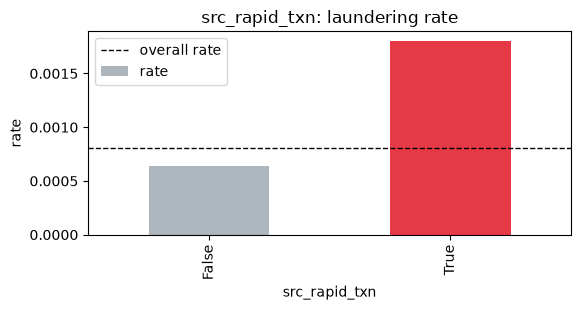

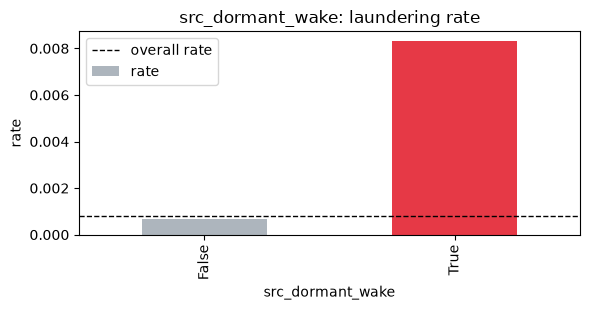

,n,positives,rate,lift
src_dormant_wake,,,,
False,3485414,2285,0.000656,0.815829
True,68652,571,0.008317,10.350235


In [23]:
train["src_rapid_txn"]    = train.src_secs_since_last <= 60
train["src_dormant_wake"] = train.src_secs_since_last > 200_000

explore_boolean(train, "src_rapid_txn")
explore_boolean(train, "src_dormant_wake")

## 7.3 Network structure — fan-in and fan-out

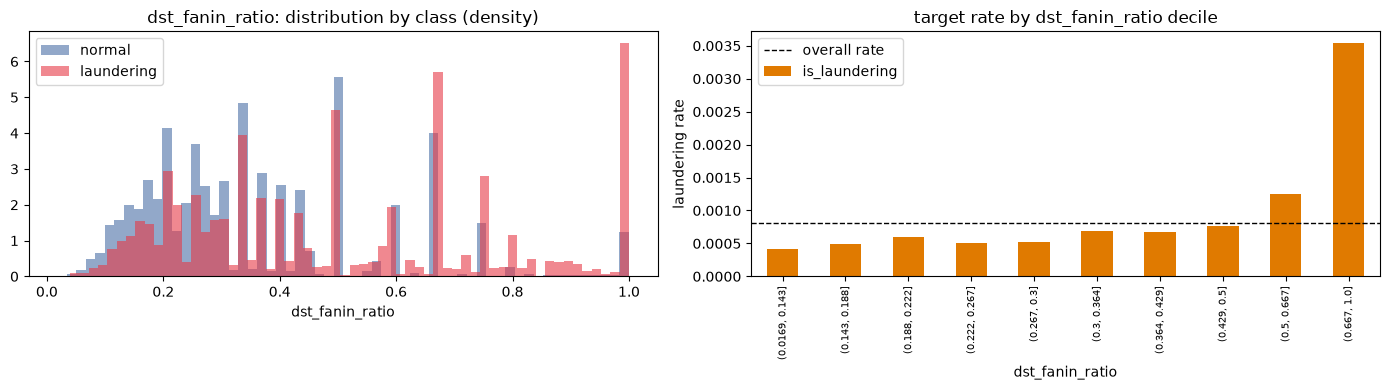

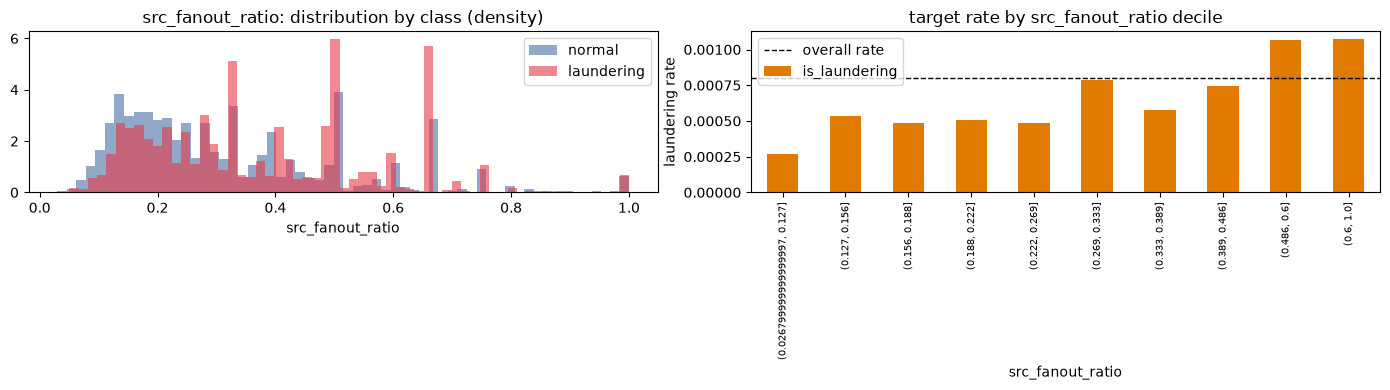

NaN share: 0.267


In [24]:
explore_numeric(train, "dst_fanin_ratio",  log_scale=False)
explore_numeric(train, "src_fanout_ratio", log_scale=False)
print("NaN share:", train.dst_fanin_ratio.isna().mean().round(3))

**What they measure.** Whether an account deals with many *different*
counterparties or the same few repeatedly. A ratio near 1.0 means every
counterparty is new; near 0.1 means the same handful over and over.

**Why it matters.** Laundering has a shape:
- **fan-out (scatter):** one account splits money across many accounts —
  breaking a large sum into inconspicuous pieces.
- **fan-in (gather):** many accounts feed into one — reassembling it.

A normal person pays the same landlord and utilities. A mule pays fifty
accounts it has never dealt with.

**Observed.**

| feature | deciles 1→10 | spread | shape |
|---|---|---|---|
| `dst_fanin_ratio` | 0.00040 → **0.0035** | 8.7× | threshold (jumps above 0.667) |
| `src_fanout_ratio` | 0.00026 → 0.0011 | 4.2× | threshold (jumps above 0.486) |

Neither is smoothly monotonic — both are flat until a sharp rise in the top
one or two deciles.

**Effect of the ≥3 guard.** Before it, laundering spiked at exactly 1.0, 0.5
and 0.667 — those were 1/1, 1/2 and 2/3 from accounts with almost no history,
reflecting newness rather than fan-out behaviour. The guard removed them.
NaN share: 26%, which XGBoost handles natively.

**Decision.** Keep both, plus an explicit `dst_high_fanin` flag since the
relationship is a threshold rather than a gradient. These are the only features
capturing **network shape** rather than properties of a single transaction —
and network shape is what laundering fundamentally is.

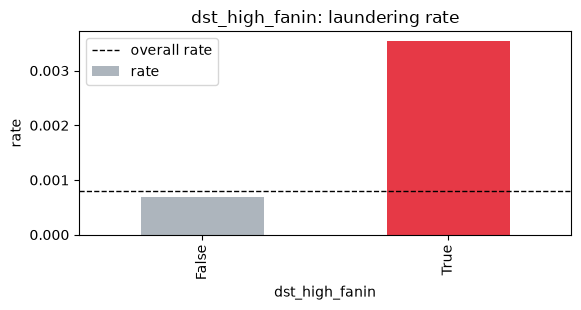

,n,positives,rate,lift
dst_high_fanin,,,,
False,3408944,2342,0.000687,0.854937
True,145122,514,0.003542,4.407549


In [25]:
train["dst_high_fanin"] = train.dst_fanin_ratio > 0.667
explore_boolean(train, "dst_high_fanin")

## 7.4 `src_log_dev` — deviation from the account's own baseline

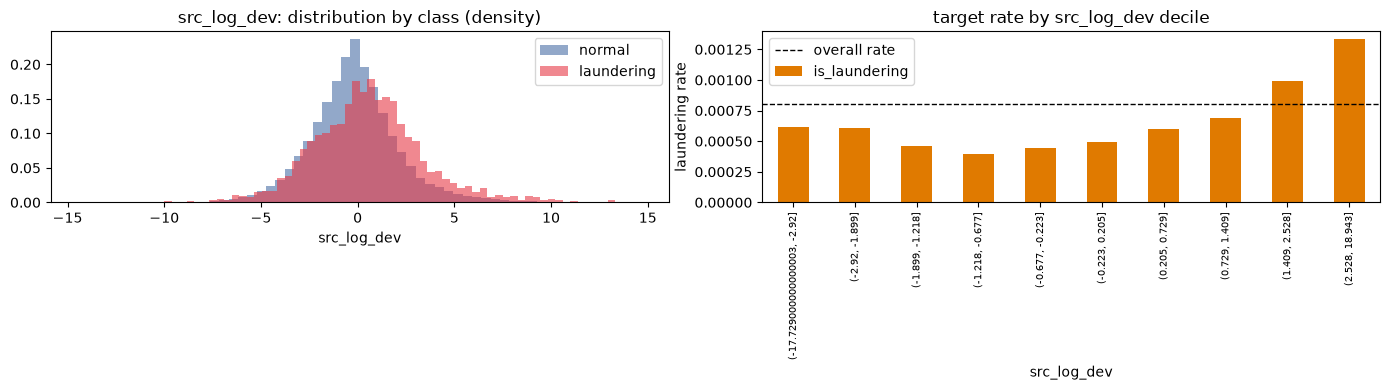

is_laundering,0,1
count,2.627947e+06,1743.000000
mean,-1.856268e-01,0.560098
std,2.325339e+00,2.819840
min,-1.772789e+01,-9.995856
25%,-1.534926e+00,-1.243457
50%,-2.235854e-01,0.493088
75%,1.037985e+00,2.111200
95%,3.739544e+00,5.492896
99%,6.561412e+00,8.965875
max,1.894305e+01,13.317856


In [26]:
explore_numeric(train, "src_log_dev", log_scale=False)

**Observed.** Centred at 0 after the geometric-mean fix. Rate falls to 0.00037
in decile 4 and rises to 0.0013 in decile 10 — **3.5× spread**, predominantly
monotonic.

An absolute-value variant was also tested (treating unusually *small* the same
as unusually *large*) and scored only 2.2×. Direction carries most of the
signal: laundering amounts tend to be larger than the account's norm, not
merely different.

**Decision.** Keep the signed version. Requires ≥3 prior transactions — a
"typical amount" from one prior transaction is meaningless.

---
# 8. Rejected features

Every rejection falls into one of four categories. None were dropped merely for
being weak.

## 8.1 Artifact — `is_cross_currency` (hypothesis test)

Cross-currency movement is a recognised layering technique, so the prior
expectation was an **elevated** rate. The observed rate is zero — the opposite
direction, and worth testing formally.

- **H₀:** laundering is independent of cross-currency status
- **H₁:** the two are associated
- **Test:** Fisher's exact (2×2; chosen over chi-square because the expected
  count in the positive/cross-currency cell is small)
- **α = 0.01**

In [27]:
table = pd.crosstab(train.is_cross_currency, train.is_laundering)
chi2, p_chi, dof, expected = chi2_contingency(table)
odds, p_fisher = fisher_exact(table)

print(table, "\n")
print("expected under H0:\n", expected.round(1), "\n")
print(f"chi-square : X2={chi2:.2f}, p={p_chi:.3e}")
print(f"fisher     : OR={odds:.4f}, p={p_fisher:.3e}")

is_laundering            0     1
is_cross_currency               
False              3503345  2856
True                 47865     0 

expected under H0:
 [[3.5033835e+06 2.8175000e+03]
 [4.7826500e+04 3.8500000e+01]] 

chi-square : X2=38.01, p=7.030e-10
fisher     : OR=0.0000, p=3.473e-17


2026-08-16 21:37:04.454 | WARNING  | aml_detection.eda:explore_boolean:227 - is_cross_currency=[True] contains ZERO positives. Either the flag is useless, or those rows can be excluded from training entirely.


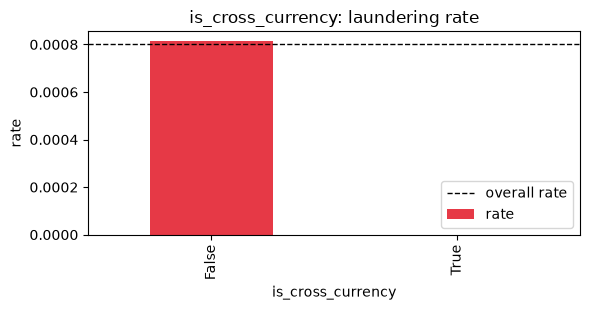

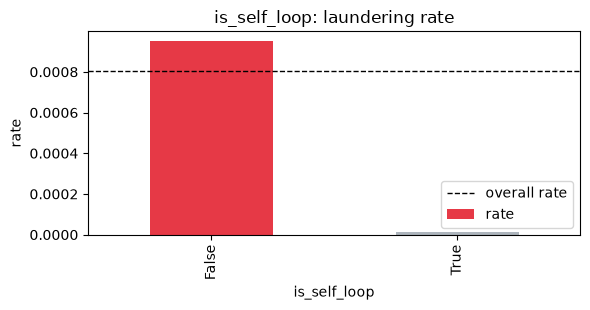

,n,positives,rate,lift
is_self_loop,,,,
False,2995264,2850,0.000952,1.184069
True,558802,6,0.000011,0.013362


In [28]:
explore_boolean(train, "is_cross_currency")
explore_boolean(train, "is_self_loop")

**Result.** Under independence, 47,865 cross-currency rows would contain ~38.5
positives. **Zero** were observed.

- Chi-square: χ² = 38.01, p = 7.03e-10
- Fisher's exact: OR = 0.0000, p = 3.47e-17

H₀ rejected by both. The p-values differ by seven orders of magnitude — the
chi-square approximation straining against an empty cell, which is precisely
why Fisher was appropriate.

**Interpretation.** The association is real, not sampling noise. But
significance establishes only that the pattern is unlikely under independence —
it does not make the feature useful. Two reasons to reject it anyway:

1. **Direction contradicts domain knowledge.** A protective effect from
   currency conversion is not plausible behaviour.
2. **A perfectly empty cell across 47,865 rows** is the signature of a
   generator constraint. Real data would show *some* overlap.

A model trained on this learns *"cross-currency ⇒ safe"* and would
systematically ignore exactly the transactions an investigator should review.

**Decision.** Drop `is_cross_currency` and `amount_delta`. Exclude self-loop
rows (also 0 positives, 11.6% of data) from training.

*The test quantifies the effect; domain judgement decides.*

**Note on multiple comparisons:** with many columns screened, at α = 0.05 one
in twenty tests would appear significant by chance. α = 0.01 was used
throughout for this reason.

## 8.2 Redundancy — correlation check

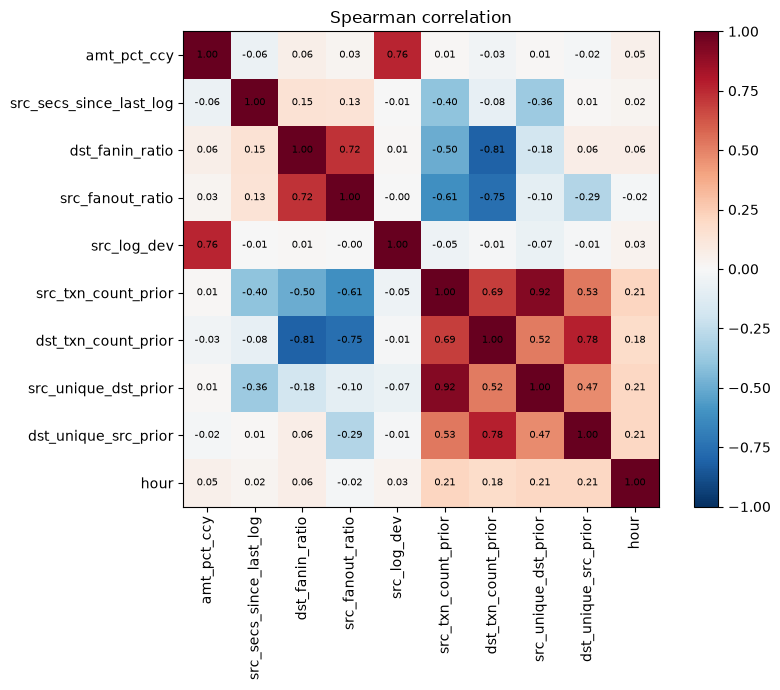

pairs above 0.7:
src_txn_count_prior  src_unique_dst_prior    0.915630
dst_fanin_ratio      dst_txn_count_prior     0.809320
dst_txn_count_prior  dst_unique_src_prior    0.780967
amt_pct_ccy          src_log_dev             0.759524
src_fanout_ratio     dst_txn_count_prior     0.750403
dst_fanin_ratio      src_fanout_ratio        0.718947
dtype: float64


In [29]:
CANDIDATES = [
    "amt_pct_ccy", "src_secs_since_last_log",
    "dst_fanin_ratio", "src_fanout_ratio", "src_log_dev",
    "src_txn_count_prior", "dst_txn_count_prior",
    "src_unique_dst_prior", "dst_unique_src_prior",
    "hour",
]

corr = train[CANDIDATES].corr(method="spearman")

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(CANDIDATES))); ax.set_xticklabels(CANDIDATES, rotation=90)
ax.set_yticks(range(len(CANDIDATES))); ax.set_yticklabels(CANDIDATES)
for i in range(len(CANDIDATES)):
    for j in range(len(CANDIDATES)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=7)
plt.colorbar(im); plt.title("Spearman correlation")
plt.tight_layout(); plt.show()

high = (corr.abs()
        .where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack().sort_values(ascending=False))
print("pairs above 0.7:"); print(high[high > 0.7])

Spearman rather than Pearson: these features are skewed and several
relationships are monotonic but not linear.

| pair | ρ | why |
|---|---|---|
| `src_unique_dst_prior` / `src_txn_count_prior` | 0.92 | numerator and denominator of the fan-out ratio |
| `dst_txn_count_prior` / `dst_fanin_ratio` | −0.81 | larger denominator drives the ratio down |
| `dst_txn_count_prior` / `dst_unique_src_prior` | 0.78 | same, incoming side |
| `amt_pct_ccy` / `src_log_dev` | 0.76 | both amount-based |
| `dst_fanin_ratio` / `src_fanout_ratio` | 0.72 | highly-connected accounts score high on both |

**Decisions.**
- **Drop the four raw counts.** They are the ratio components and add no
  independent information.
- **Keep both fan ratios** despite ρ = 0.72 — they describe opposite ends of a
  chain. Expect their SHAP importances to split unpredictably.
- **`src_log_dev` is marginal** (ρ = 0.76 with a far stronger feature).
  Retained; test whether removing it changes PR-AUC.

**On VIF:** not run. VIF detects multicollinearity that destabilises *linear
model coefficients*. XGBoost has no coefficients and handles correlated
features by picking one per split — prediction quality is unaffected. Pairwise
correlation is sufficient for the redundancy check here.

## 8.3 Mechanical artifacts and superseded formulations

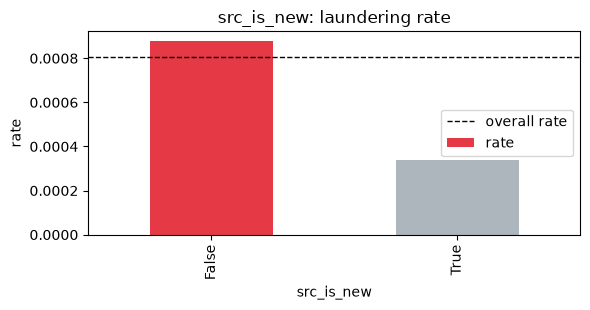

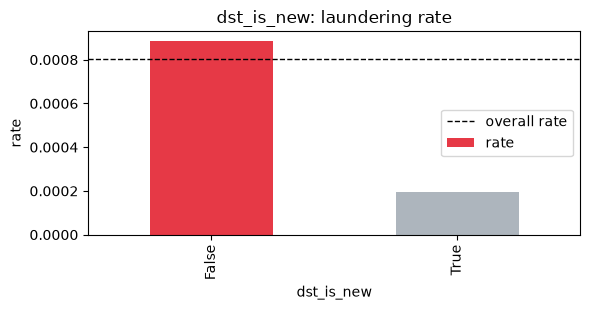

In [30]:
for col in ["src_is_new", "dst_is_new"]:
    if col not in train:
        train[col] = train[f"{col[:3]}_txn_count_prior"] == 0
    explore_boolean(train, col)

**`src_is_new` / `dst_is_new`.** Both show *lower* laundering (0.00033 and
0.00020 vs 0.00088 base). Mechanical rather than behavioural — a first
transaction has no history so cannot yet be part of a chain. The direction also
contradicts real AML practice, where new accounts are elevated risk.
**Rejected**, or kept only as a NaN indicator.

**`src_amount_vs_own_mean`.** Max 3.5e7, U-shaped and unusable. Superseded by
`src_log_dev`.

**`src_log_dev_abs`.** 2.2× vs 3.5× signed — discards direction, which carries
most of the signal.

---
# 9. Final feature set

| feature | spread | shape | family |
|---|---|---|---|
| `src_secs_since_last_log` | **60×** | U-shaped | timing |
| `amt_pct_ccy` | **40×** | band | amount |
| `src_dormant_wake` | 10.3× | boolean | timing |
| `dst_fanin_ratio` | 8.7× | threshold | network |
| `payment_format` | 7.3× | categorical | raw |
| `hour_sin` / `hour_cos` | 6× | cyclical | time |
| `src_fanout_ratio` | 4.2× | threshold | network |
| `src_log_dev` | 3.5× | monotonic | behaviour |
| `src_rapid_txn` | 3.3× | boolean | timing |
| `dst_high_fanin` | — | boolean | network |
| `is_hour_zero` | — | boolean | data quality |
| entity type / bank country (×4) | ~1.3× | categorical | account |

**Rejected, with reason**

| feature | category | reason |
|---|---|---|
| `is_cross_currency`, `amount_delta` | artifact | 0 positives in 47,865 rows; χ² p=7e-10, Fisher p=3.5e-17. Real association, wrong direction |
| `is_self_loop` | artifact | 0 positives; exclude those rows instead |
| `amt_logz_ccy`, `log_amount` | redundant | ρ = 0.955 with `amt_pct_ccy` |
| four raw prior-counts | redundant | ρ up to 0.92 with the ratios |
| `src_log_dev_abs` | superseded | 2.2× vs 3.5× signed |
| `src_amount_vs_own_mean` | superseded | arithmetic mean inflated by outliers |
| `src_is_new`, `dst_is_new` | mechanical | wrong direction, no behavioural content |
| `day_of_week` | artifact | 10-day window, 1-2 observations per weekday |

**Training row exclusions:** Reinvestment, Wire, self-loops, burn-in period.

In [31]:
FEATURES = [
    "amt_pct_ccy",
    "src_secs_since_last_log", "src_rapid_txn", "src_dormant_wake",
    "dst_fanin_ratio", "dst_high_fanin", "src_fanout_ratio",
    "src_log_dev",
    "hour_sin", "hour_cos", "is_hour_zero",
    "payment_format",
    "src_entity_type", "dst_entity_type",
    "src_bank_country", "dst_bank_country",
]
print(len(FEATURES), "features")
train[FEATURES].dtypes

16 features


amt_pct_ccy                 float64
src_secs_since_last_log     float64
src_rapid_txn                  bool
src_dormant_wake               bool
dst_fanin_ratio             float64
dst_high_fanin                 bool
src_fanout_ratio            float64
src_log_dev                 float64
hour_sin                    float64
hour_cos                    float64
is_hour_zero                   bool
payment_format             category
src_entity_type              object
dst_entity_type              object
src_bank_country             object
dst_bank_country             object
dtype: object

---
# 10. Implications for modelling

**1. Not one top feature is linear-monotonic.**

Amount is a band. Timing is U-shaped. Fan-in and fan-out are thresholds.
Payment format is categorical. A linear model can only learn one direction —
it cannot represent "both extremes are risky".

→ **XGBoost as primary model. Logistic regression as an interpretable
baseline for comparison, not as a contender.**

**2. Metrics must suit a 0.08% positive rate.**

→ **PR-AUC as headline, plus recall at a fixed alert budget** — if
investigators review 500 alerts a day, what share of laundering is caught?
That is the question an AML team actually asks.

**3. Cost asymmetry favours recall.**

A missed STR is a regulatory failure; a false positive costs investigator time.
Threshold selection should target a recall level and report the precision cost,
rather than defaulting to 0.5.

**4. A rules baseline comes first.**

Detection rules are the incumbent in any real AML function. The model's result
should be stated as lift *over rules*, not as a standalone AUC.

---
# 11. Known limitations

**Simulator artifacts.** Zero laundering on Wire, Reinvestment and
cross-currency transactions are properties of the generator, not of banking.
All three are genuine laundering channels in reality. Any model trained here
inherits those blind spots.

**Window dependence.** 10 days of data. The dormancy threshold (200,000s ≈ 2.3
days) is ~23% of the observation window and would need refitting on longer
data.

**Timestamp resolution.** Minute-granular — sub-minute thresholds return
identical results.

**Chain truncation.** Chains beginning near day 10 are cut by the file
boundary, so some positives are partial patterns. The model trains largely on
completed chains; in production it would see chains still in progress, and
recall on in-flight laundering would likely be lower.

**Offline/online mismatch.** Features are computed batch-wise over full
history. Production would maintain account aggregates incrementally in a
feature store. The definitions here are the specification the online store must
reproduce — keeping them consistent is the primary train-serve skew risk.

---
# 12. Next

1. Port `FEATURES` into `features.py` with a leakage regression test.
2. Build the rules baseline; measure its precision and recall.
3. Train LR → RF → XGBoost; report PR-AUC and recall@k **against the
   baseline**.
4. Per-typology recall using the pattern labels — **evaluation only**. Those
   labels are generator ground truth that would not exist at a real bank, so
   they are never used for sampling, features, or model selection.